In [4]:
#파일 열기
import pandas as pd

df = pd.read_csv('Iris.csv')

In [5]:
df   #파일 확인   6행 150열/ dispaly로도 볼 수 있음

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [6]:
df.info()   #파일 기본정보 체크   공백 없고 숫자행은 5개(정수1 실수4)+문자행(이름) 한개

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [7]:
print(df.isna().sum())   #누락확인/ sum 안붙이면 전체에 T/F로 보여주고 sum 하면 행별 sum 하나 더 붙이면 전체

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [8]:
df.describe()    #각 값들/ 꽃받침 길이 평균: 5.84, 꽃잎 최대 너비: 2.5

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [9]:
df['PetalWidthCm'].max()          #이렇게 낱개로도 구해짐
print(df['PetalWidthCm'].max())
df['SepalLengthCm'].mean()

2.5


np.float64(5.843333333333334)

In [10]:
df['Species'].value_counts()   #꽃 종류별 개수 세기/그냥 카운트는 개수, 벨류카운트해야 값을 보고 같은거 개수를 세줌

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [11]:
#df['PetalLengthCm'] > 2   #이렇게 하면 걍 조건문으로 먹어서 T/F로만 띄워줌
df[df['PetalLengthCm'] > 2].count()
#100개로 뜨긴 하는데 각 행마다 하나씩 띄워줌. 이걸 합치기 위해 .sum()을 쓰면 600이 나옴 다른 방법은 없나?
#len으로도 구할 수 있음, 아님 카운트 없이 썸()만 붙이면 자동으로 개수 나옴
df[df['PetalLengthCm'] > 2].sum()
len(df[df['PetalLengthCm'] > 2])

100

In [12]:
df[df['SepalWidthCm'] > 3.5]

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
10,11,5.4,3.7,1.5,0.2,Iris-setosa
14,15,5.8,4.0,1.2,0.2,Iris-setosa
15,16,5.7,4.4,1.5,0.4,Iris-setosa
16,17,5.4,3.9,1.3,0.4,Iris-setosa
18,19,5.7,3.8,1.7,0.3,Iris-setosa
19,20,5.1,3.8,1.5,0.3,Iris-setosa
21,22,5.1,3.7,1.5,0.4,Iris-setosa
22,23,4.6,3.6,1.0,0.2,Iris-setosa


In [13]:
df[df['Species'] == 'Iris-versicolor']['PetalLengthCm'].mean()
#괜히 뭐 and , . 이런거 붙이지 말고 바로 대괄호 치고 이으면 됨

np.float64(4.26)

In [14]:
df[df['Species'] == 'Iris-virginica']['SepalWidthCm'].max()

3.8

In [15]:
#12. 종류별 평균 비교하기, 꽃 마다의 평균을 구해 비교-직접
a=df[df['Species'] == 'Iris-setosa']['SepalLengthCm'].mean()
b=df[df['Species'] == 'Iris-versicolor']['SepalLengthCm'].mean()
c=df[df['Species'] == 'Iris-virginica']['SepalLengthCm'].mean()
print(a,b,c)
df_Sepal={'Iris-setosa': a, 'Iris-versicolor': b, 'Iris-virginica': c }
df_Sepal

5.006 5.936 6.587999999999998


{'Iris-setosa': np.float64(5.006),
 'Iris-versicolor': np.float64(5.936),
 'Iris-virginica': np.float64(6.587999999999998)}

In [16]:
# 12. 종류별 평균표 만들기-AI에게 프롬프팅한 결과
table = (df.groupby('Species', as_index=True)[['SepalLengthCm', 'PetalWidthCm']]
           .mean()
           .rename(columns={'SepalLengthCm':'SepalLength_mean', 'PetalWidthCm':'PetalWidth_mean'})
           .round(2)
           .sort_index())

# 2) "가장 큰 평균"을 갖는 Species 찾기
longest_sepal_species = table['SepalLength_mean'].idxmax()
widest_petal_species  = table['PetalWidth_mean'].idxmax()

# 3) 보기 좋게 하이라이트해서 표로 출력(코랩/주피터에서 예쁨)
styled = (table.style
          .set_caption("Species별 평균 (SepalLength, PetalWidth)")
          .format("{:.2f}")
          .set_properties(**{'text-align': 'center'})
          .set_table_styles([
              {'selector': 'caption', 'props': [('font-size','16px'), ('font-weight','600'), ('text-align','left')]},
              {'selector': 'th', 'props': [('text-align','center'), ('background-color','#f4f4f4')]}
          ])
          .apply(lambda col: ['background-color:#fff2a8' if i==col.idxmax() else '' for i in col.index],
                 subset=['SepalLength_mean'])
          .apply(lambda col: ['background-color:#b7f7c5' if i==col.idxmax() else '' for i in col.index],
                 subset=['PetalWidth_mean'])
         )

display(styled)

,SepalLength_mean,PetalWidth_mean
Species,,
Iris-setosa,5.01,0.24
Iris-versicolor,5.94,1.33
Iris-virginica,6.59,2.03


In [17]:
#12.종류별 평균 비교 교수님 버전
cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

means = df.groupby('Species')[cols].mean().round(2)
print(means)

print("꽃받침 가장 긴 종:", means['SepalLengthCm'].idxmax())
print("꽃잎 가장 넓은 종:", means['PetalWidthCm'].idxmax())

                 SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
Species                                                                  
Iris-setosa               5.01          3.42           1.46          0.24
Iris-versicolor           5.94          2.77           4.26          1.33
Iris-virginica            6.59          2.97           5.55          2.03
꽃받침 가장 긴 종: Iris-virginica
꽃잎 가장 넓은 종: Iris-virginica


In [32]:
#15.새로운 값 계산하기
df['SepalArea'] = df['SepalLengthCm'] * df['SepalWidthCm']
df[ 'PetalArea'] = df['PetalLengthCm'] * df['PetalWidthCm']
area_mean = df.groupby( 'Species')[[ 'SepalArea', 'PetalArea']].mean().round()
print (area_mean)
print("꽃받침 면적 최대:", area_mean['SepalArea'].idxmax())
print("꽃잎 면적 최대:", area_mean['PetalArea'].idxmax()) # virginica

                 SepalArea  PetalArea
Species                              
Iris-setosa           17.0        0.0
Iris-versicolor       17.0        6.0
Iris-virginica        20.0       11.0
꽃받침 면적 최대: Iris-virginica
꽃잎 면적 최대: Iris-virginica


In [19]:
# 15. 새로운 값 계산 + Species별 평균 + 최대 Species 찾기-AI

# (1) 면적 컬럼 생성
df['SepalArea'] = df['SepalLengthCm'] * df['SepalWidthCm']
df['PetalArea'] = df['PetalLengthCm'] * df['PetalWidthCm']

# (2) Species별 평균 면적 계산 (반올림)
area_mean = df.groupby('Species')[['SepalArea', 'PetalArea']].mean().round(2)

# (3) 결과 출력
print(area_mean)

# (4) 최대 평균을 갖는 Species 출력
print("꽃받침 면적 최대:", area_mean['SepalArea'].idxmax())
print("꽃잎 면적 최대:", area_mean['PetalArea'].idxmax())

                 SepalArea  PetalArea
Species                              
Iris-setosa          17.21       0.36
Iris-versicolor      16.53       5.72
Iris-virginica       19.68      11.30
꽃받침 면적 최대: Iris-virginica
꽃잎 면적 최대: Iris-virginica


In [21]:
#16. 데이터 필터링
#df[df['SepalWidthCm']>=3] and df[df['PetalWidthCm']>=1.5]    #조건 다는거라 and나 콤마로 될 줄 알았는데 안됨-& 사용

In [22]:
#직접한 데이터 필터링
df[(df['SepalWidthCm']>=3) & (df['PetalWidthCm']>=1.5)]

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,SepalArea,PetalArea
51,52,6.4,3.2,4.5,1.5,Iris-versicolor,20.48,6.75
52,53,6.9,3.1,4.9,1.5,Iris-versicolor,21.39,7.35
56,57,6.3,3.3,4.7,1.6,Iris-versicolor,20.79,7.52
61,62,5.9,3.0,4.2,1.5,Iris-versicolor,17.70,6.30
66,67,5.6,3.0,4.5,1.5,Iris-versicolor,16.80,6.75
70,71,5.9,3.2,4.8,1.8,Iris-versicolor,18.88,8.64
77,78,6.7,3.0,5.0,1.7,Iris-versicolor,20.10,8.50
84,85,5.4,3.0,4.5,1.5,Iris-versicolor,16.20,6.75
85,86,6.0,3.4,4.5,1.6,Iris-versicolor,20.40,7.20
86,87,6.7,3.1,4.7,1.5,Iris-versicolor,20.77,7.05


In [23]:
#교수님이 한 데이터 필터링-보니까 필터라는 변수에 조건에 맞는 표를 넣어서 복잡하지 않게 정렬함
filtered = df.loc[(df['SepalWidthCm'] >= 3.0) & (df['PetalWidthCm'] >= 1.5)]
print("조건충족데이터:", len(filtered))
print(filtered['Species'].value_counts())

조건충족데이터: 39
Species
Iris-virginica     29
Iris-versicolor    10
Name: count, dtype: int64


In [24]:
#조건에 맞게 상위 10개 값 뽑아내기 이후 어떤 꽃이 가장 많은지 확인
top10 = df.sort_values('SepalLengthCm',ascending=False).head(10)
print(top10['Species'].value_counts())

Species
Iris-virginica    10
Name: count, dtype: int64


In [33]:
# [코드 11-49, 11-50] 한글 폰트 설치 (Colab 환경)    이거 설치 안하면ㅁ 그래프 만들때 한글 다 깨짐
!apt-get update -qq                         # ! 붙는게 특징인데 외부명령어임 얘네는
!apt-get install fonts-nanum -qq
!fc-cache -fv

import matplotlib.font_manager as fm
font10 = fm.FontProperties(fname='/usr/share/fonts/truetype/nanum/NanumGothic.ttf',size=10)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped dire

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44867 (\N{HANGUL SYLLABLE GGOC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51086 (\N{HANGUL SYLLABLE IP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

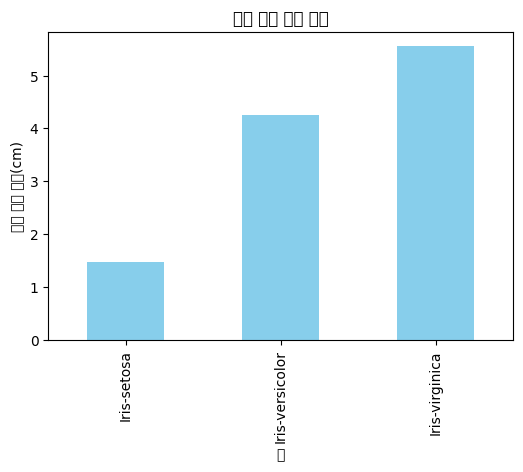

In [35]:
#13-1 막대그래프 평균 비교하기
import matplotlib.pyplot as plt #그래프 불러오는 함수
# 꽃별 평균 조건
petal_mean = df.groupby('Species')['PetalLengthCm'].mean()

plt.rc('font',family="NanumBarunGothic")  #쥬피터에선 이거 하면 해결 되는데 코랩에선 안됨. 런타임 초기화해도 안됨. 걍 그때그때 다르게 해결하는거라 하심
a = petal_mean.plot(kind='bar', figsize=(6,4), color='skyblue')
a.set_title('종별 꽃잎 길이 평균')
a.set_xlabel('종')
a.set_ylabel('꽃잎 길이 평균(cm)')
plt.show()

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


/tmp/ipykernel_37381/3110222865.py:44: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_37381/3110222865.py:44: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_37381/3110222865.py:44: UserWarning: Glyph 52629 (\N{HANGUL SYLLABLE CUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_37381/3110222865.py:44: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_37381/3110222865.py:44: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_37381/3110222865.py:44: UserWarning: Glyph 44544 (\N{HANGUL SYLLABLE GEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_37381/3110222865.py:44: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tig

적용 폰트: NanumGothic
폰트 경로: /usr/share/fonts/truetype/nanum/NanumGothic.ttf
backend: module://matplotlib_inline.backend_inline


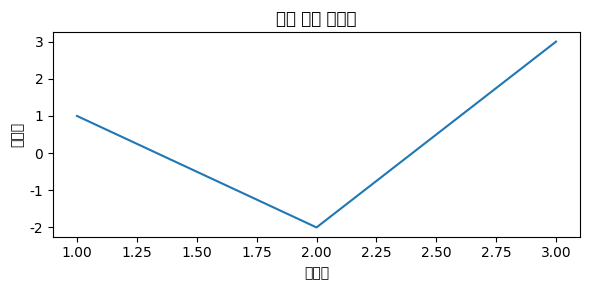

In [37]:
# Colab 한글 폰트 "한 방에" 해결 (설치 + matplotlib 캐시 삭제 + 강제 적용)-산지니가 알려준 최후의 방법인데 깨짐. 영어로 하는게 속편할듯

!apt-get update -qq
!apt-get install -y fonts-nanum -qq
!fc-cache -fv > /dev/null

import os, glob, shutil
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1) matplotlib 폰트 캐시 강제 삭제 (세션 재시작보다 이게 더 확실한 경우 많음)
cache_dir = Path(matplotlib.get_cachedir())
for p in cache_dir.glob("fontlist*"):
    p.unlink()

# 2) 폰트 경로를 '존재하는 것'으로 자동 탐색 (NanumGothic 우선)
candidates = [
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
    "/usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf",
]
candidates += glob.glob("/usr/share/fonts/**/NanumGothic*.ttf", recursive=True)
candidates += glob.glob("/usr/share/fonts/**/Nanum*.ttf", recursive=True)

font_path = next((p for p in candidates if os.path.exists(p)), None)
assert font_path is not None, "나눔 폰트 파일을 찾지 못했습니다. (설치 실패 가능)"

# 3) 폰트 '파일 경로' 기반으로 matplotlib 전역 폰트 적용 (이게 제일 강제력이 셈)
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print("적용 폰트:", font_name)
print("폰트 경로:", font_path)
print("backend:", matplotlib.get_backend())

# 4) 테스트
plt.figure(figsize=(6,3))
plt.plot([1,2,3],[1,-2,3])
plt.title("한글 제목 테스트")
plt.xlabel("가로축")
plt.ylabel("세로축")
plt.tight_layout()
plt.show()

import seaborn as sns
sns.set_theme(rc={"font.family": plt.rcParams["font.family"]})

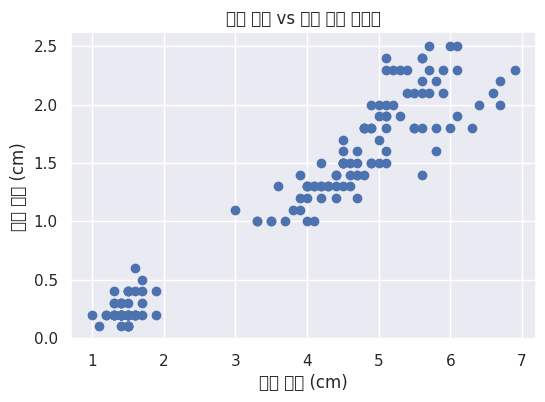

In [42]:
#10. 산점도 그리기
import matplotlib.pyplot as plt #불러오기 함수

#그래프 만들기 세팅
plt.figure(figsize=(6,4))  #크기 지정
plt.scatter(df['PetalLengthCm'],df['PetalWidthCm'])   #x, y 값 지정
plt.title("꽃잎 길이 vs 꽃잎 너비 산점도")   #제목
plt.xlabel("꽃잎 길이 (cm)")  #x 라벨
plt.ylabel("꽃잎 너비 (cm)")  #y 라벨
plt.show()  #그래프 시각화

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44867 (\N{HANGUL SYLLABLE GGOC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51086 (\N{HANGUL SYLLABLE IP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45320 (\N{HANGUL SYLLABLE NEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

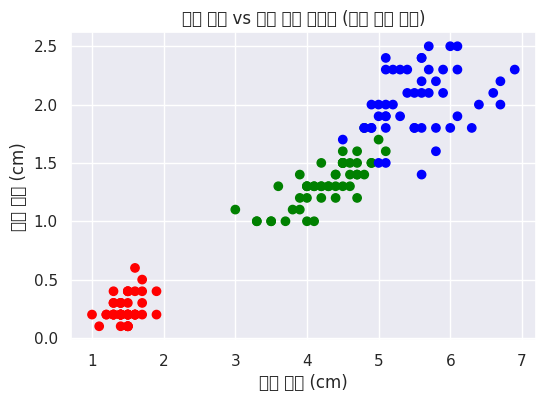

In [44]:
#문제 11
import matplotlib.pyplot as plt

colors = {
    "Iris-setosa": "red",
    "Iris-versicolor": "green",
    "Iris-virginica": "blue"
}

c = df["Species"].map(colors)   # 각 행마다 색으로 변환, map으로 전체 적용

plt.figure(figsize=(6,4))
plt.scatter(df["PetalLengthCm"], df["PetalWidthCm"], c=c)
plt.title("꽃잎 길이 vs 꽃잎 너비 산점도 (종별 지정 색상)")
plt.xlabel("꽃잎 길이 (cm)")
plt.ylabel("꽃잎 너비 (cm)")
plt.show()

In [ ]:
#시각화는 머신러닝에 앞서 데이터의 분포 등을 한눈에 보기 위한 과정
#그 과정에서 박스플롯 등으로 이상치를 잡아내기도 함
#즉 데이터를 읽어와서 info, isna, describe 등으로 데이터 프레임을 확인하고 전처리해 그래프로 시각화해 본 후 머신러닝하는 3단계 과정이라고 볼 수 있음

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48149 (\N{HANGUL SYLLABLE BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

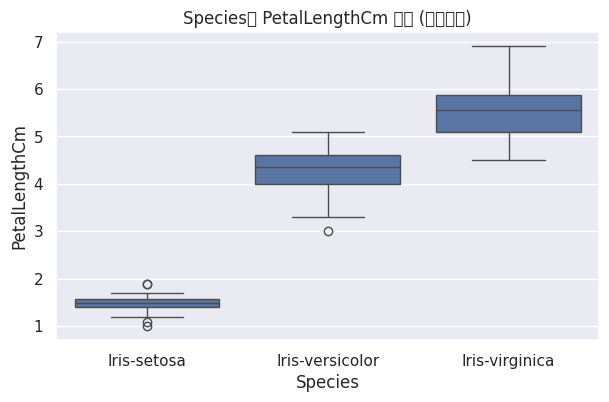

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="Species", y="PetalLengthCm")
plt.title("Species별 PetalLengthCm 분포 (박스플롯)")
plt.xlabel("Species")
plt.ylabel("PetalLengthCm")
plt.show()